# Hello Soft Clustering (GMM)

### T1.



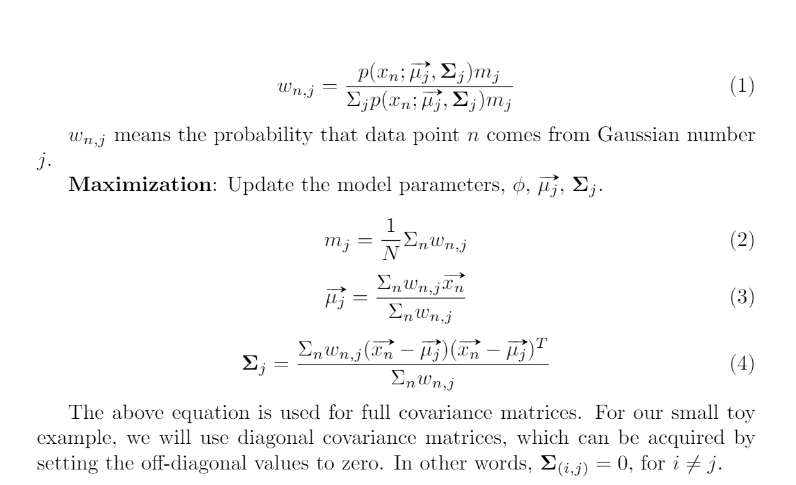

TODO: Complete functions below including
- Fill relevant parameters in each function.
- Implement computation and return values.

These functions will be used in T1-4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hint: You can use this function to get gaussian distribution.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html
from scipy.stats import multivariate_normal

In [2]:
class GMM:
    def __init__(self, mixture_weight, mean_params, cov_params):
        """
        Initialize GMM.
        """
        # Copy construction values.
        self.mixture_weight = mixture_weight
        self.mean_params = mean_params
        self.cov_params = cov_params

        # Initiailize iteration.
        self.n_iter = 0

    def estimation_step(self, data):
        """
        TODO: Perform estimation step. Then, return w_{n,j} in eq. 1)
        """

        num_samples = data.shape[0]
        num_components = len(self.mixture_weight)
        w = np.zeros((num_samples, num_components))

        for j in range(num_components):
            w[:, j] = self.mixture_weight[j] * multivariate_normal.pdf(data, self.mean_params[j], self.cov_params[j])

        w /= w.sum(axis=1, keepdims=True)

        return w


    def maximization_step(self, data, w):
        """
        TODO: Perform maximization step.
            (Update parameters in this GMM model.)
        """
        N = data.shape[0]
        sum_w = np.sum(w, axis=0)

        self.mixture_weight = sum_w / N

        for j in range(len(self.mixture_weight)):
            self.mean_params[j] = np.sum(w[:, j, np.newaxis] * data, axis=0) / sum_w[j]
            diff = data - self.mean_params[j]
            diag_cov = np.sum(w[:, j, np.newaxis] * (diff**2), axis=0) / sum_w[j]
            self.cov_params[j] = np.diag(diag_cov)


    def get_log_likelihood(self, data):
        """
        TODO: Compute log likelihood.
        """
        num_components = len(self.mixture_weight)
        probs = np.zeros((data.shape[0], num_components))
        
        for j in range(num_components):
            probs[:, j] = self.mixture_weight[j] * multivariate_normal.pdf(data, self.mean_params[j], self.cov_params[j])
        
        log_prob = np.sum(np.log(np.sum(probs, axis=1)))
        return log_prob

    def print_iteration(self, w):
        print("m :\n", self.mixture_weight)
        print("mu :\n", self.mean_params)
        print("covariance matrix :\n", self.cov_params)
        if w is not None:
            print("w :\n", w)
        print("-------------------------------------------------------------")

    def perform_em_iterations(self, data, num_iterations, display=True):
        """
        Perform estimation & maximization steps with num_iterations.
        Then, return list of log_likelihood from those iterations.
        """
        log_prob_list = []

        # Display initialization.
        if display:
            print("Initialization")
            self.print_iteration(None)

        for n_iter in range(num_iterations):

            # TODO: Perform EM step.
            w = self.estimation_step(data)
            self.maximization_step(data, w)



            # Calculate log prob.
            log_prob = self.get_log_likelihood(data)
            log_prob_list.append(log_prob)

            # Display each iteration.
            if display:
                print(f"Iteration: {n_iter}")
                self.print_iteration(w)

        return log_prob_list

### T1.1

In [3]:
num_iterations = 3
num_mixture = 3
mixture_weight = [1] * num_mixture # m
mean_params = np.array([[3,3], [2,2], [-3,-3]], dtype = float)
cov_params = np.array([np.eye(2)] * num_mixture)

X, Y = np.array([1, 3, 2, 8, 6, 7, -3, -2, -7]), np.array([2, 3, 2, 8, 6, 7, -3, -4, -7])
data = np.vstack([X,Y]).T

gmm = GMM(mixture_weight, mean_params, cov_params)
log_prob_list = gmm.perform_em_iterations(data, num_iterations)

Initialization
m :
 [1, 1, 1]
mu :
 [[ 3.  3.]
 [ 2.  2.]
 [-3. -3.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------
Iteration: 0
m :
 [0.45757242 0.20909425 0.33333333]
mu :
 [[ 5.78992692  5.81887265]
 [ 1.67718211  2.14523106]
 [-4.         -4.66666666]]
covariance matrix :
 [[[4.53619412 0.        ]
  [0.         4.28700611]]

 [[0.51645579 0.        ]
  [0.         0.13152618]]

 [[4.66666668 0.        ]
  [0.         2.88888891]]]
w :
 [[1.19202922e-01 8.80797076e-01 1.81545808e-09]
 [7.31058579e-01 2.68941421e-01 1.69570706e-16]
 [2.68941421e-01 7.31058579e-01 1.01529005e-11]
 [9.99983299e-01 1.67014218e-05 2.03105874e-42]
 [9.99088949e-01 9.11051194e-04 5.37528453e-32]
 [9.99876605e-01 1.23394576e-04 3.30529272e-37]
 [2.31952283e-16 1.38879439e-11 1.00000000e+00]
 [2.31952283e-16 1.38879439e-11 1.00000000e+00]
 [3.30570063e-37 5.90009054e-29 1.00000000e+00]]
-------------------

### T2.

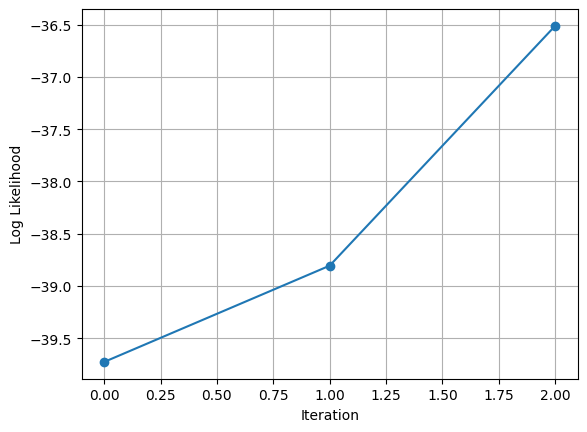

In [4]:
plt.plot(range(len(log_prob_list)), log_prob_list, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Log Likelihood')
plt.grid(True)

Yes, the log-likelihood does goes up in eavery iteration

### T3.



In [11]:
num_iterations = 3

num_mixture = 2
mixture_weight = [1] * num_mixture

mean_params = np.array([[3,3], [-3,-3]], dtype = float)
cov_params = np.array([np.eye(2)] * num_mixture)

X, Y = np.array([1, 3, 2, 8, 6, 7, -3, -2, -7]), np.array([2, 3, 2, 8, 6, 7, -3, -4, -7])
data = np.vstack([X,Y]).T

gmm2 = GMM(mixture_weight, mean_params, cov_params)
log_prob_list2 = gmm2.perform_em_iterations(data, num_iterations)

Initialization
m :
 [1, 1]
mu :
 [[ 3.  3.]
 [-3. -3.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------
Iteration: 0
m :
 [0.66666666 0.33333334]
mu :
 [[ 4.50000001  4.66666667]
 [-3.99999997 -4.66666663]]
covariance matrix :
 [[[6.91666665 0.        ]
  [0.         5.88888889]]

 [[4.66666677 0.        ]
  [0.         2.8888891 ]]]
w :
 [[9.99999985e-01 1.52299795e-08]
 [1.00000000e+00 2.31952283e-16]
 [1.00000000e+00 3.77513454e-11]
 [1.00000000e+00 2.03109266e-42]
 [1.00000000e+00 5.38018616e-32]
 [1.00000000e+00 3.30570063e-37]
 [2.31952283e-16 1.00000000e+00]
 [2.31952283e-16 1.00000000e+00]
 [3.30570063e-37 1.00000000e+00]]
-------------------------------------------------------------
Iteration: 1
m :
 [0.66669436 0.33330564]
mu :
 [[ 4.49961311  4.66620178]
 [-3.99993241 -4.66651231]]
covariance matrix :
 [[[6.91944755 0.        ]
  [0.         5.89275124]]

 [[4.66806942 0.        ]
  [0.         2.

### T4.

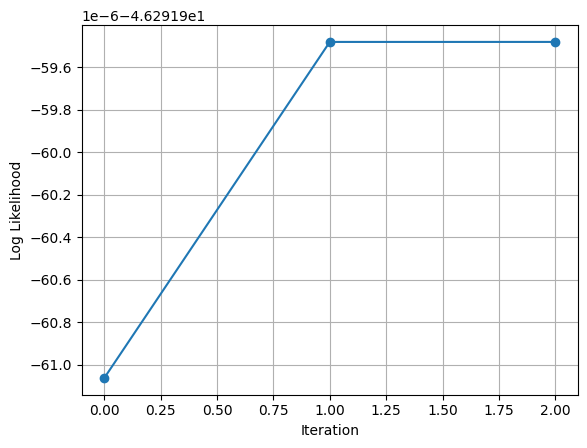

In [12]:
plt.plot(range(len(log_prob_list2)), log_prob_list2, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Log Likelihood')
plt.grid(True)

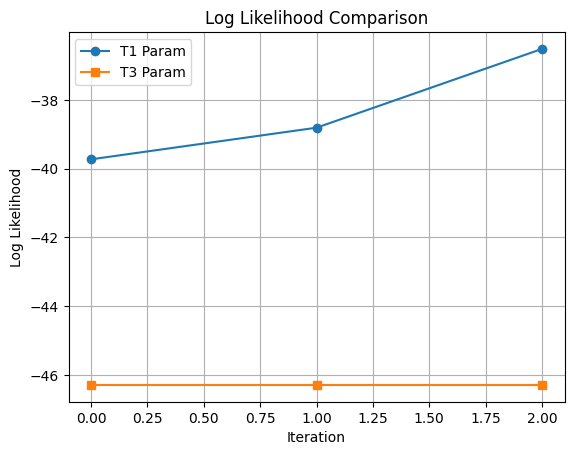

In [17]:
plt.plot(range(len(log_prob_list)), log_prob_list, marker='o', label='T1 Param')
plt.plot(range(len(log_prob_list2)), log_prob_list2, marker='s', label='T3 Param')

plt.title('Log Likelihood Comparison')
plt.xlabel('Iteration')
plt.ylabel('Log Likelihood')
plt.legend()
plt.grid(True)

From the plot, is it clear that the mixture from T1 is better than mixture from T3 is terms of log0likelihood

### OT1.

In [20]:
num_iterations = 3
num_mixture = 2
mixture_weight = [1] * num_mixture # m
mean_params = np.array([[0,0], [10000,10000]], dtype = float)
cov_params = np.array([np.eye(2)] * num_mixture)

X, Y = np.array([1, 3, 2, 8, 6, 7, -3, -2, -7]), np.array([2, 3, 2, 8, 6, 7, -3, -4, -7])
data = np.vstack([X,Y]).T

gmm3 = GMM(mixture_weight, mean_params, cov_params)
try:
   log_prob_list3 = gmm3.perform_em_iterations(data, num_iterations)
except Exception as e:
   print(f"Error: {type(e).__name__} - {e}")

Initialization
m :
 [1, 1]
mu :
 [[    0.     0.]
 [10000. 10000.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------
Error: ValueError - array must not contain infs or NaNs


C:\Users\USER\AppData\Local\Temp\ipykernel_29060\2396485036.py:42: RuntimeWarning: invalid value encountered in divide
  self.mean_params[j] = np.sum(w[:, j, np.newaxis] * data, axis=0) / sum_w[j]


From the above, the code cant seem to actually run from the absurd means. By having mean being really far from each data point, our distance function become very large positive number and result in our means became Nan from dividing by 0

The solution to prevent that situation is simple, we can run a quick K-means algorithm first to get our estimated means or we can select a mean from any of starting datapoint (random with equal weight, reselect upon failure). 

However if the extreme mean cannot be evade (some datapoint is extremely faraway), we can add epsilon (eg. 1e-6) to our cov matrices to prevent zero or using np.clip to w in order to prevent w from actually reaching 0

# The face database

In [5]:
# Download facedata for google colab
# %wget -nc https://github.com/ekapolc/Pattern_2024/raw/main/HW/HW03/facedata_mat.zip
# %unzip facedata_mat.zip

In [5]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import img_as_float

# Change path to your facedata.mat file.
facedata_path = 'facedata.mat'

data = scipy.io.loadmat(facedata_path)
data_size = data['facedata'].shape

%matplotlib inline
data_size

(40, 10)

### Preprocess xf

In [6]:
xf = np.zeros((data_size[0], data_size[1], data['facedata'][0,0].shape[0], data['facedata'][0,0].shape[1]))
for i in range(data['facedata'].shape[0]):
    for j in range(data['facedata'].shape[1]):
        xf[i,j] = img_as_float(data['facedata'][i,j])

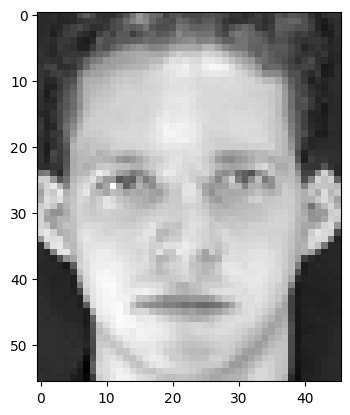

In [7]:
# Example: Ploting face image.
plt.imshow(xf[0,0], cmap = 'gray')
plt.show()

### T5

In [8]:
def L2_dist(x1, x2):
    """
    TODO: Calculate L2 distance.
    """
    return np.linalg.norm(x1 - x2)

# Test L2_dist
def test_L2_dist():
    assert L2_dist(np.array([1, 2, 3]), np.array([1, 2, 3])) == 0.0
    assert  L2_dist(np.array([0, 0, 0]), np.array([1, 2, 3])) == np.sqrt(14)

test_L2_dist()

print('Euclidean distance between xf[0,0] and xf[0,1] is', L2_dist(xf[0,0], xf[0,1]))
print('Euclidean distance between xf[0,0] and xf[1,0] is', L2_dist(xf[0,0], xf[1,0]))

Euclidean distance between xf[0,0] and xf[0,1] is 10.037616294165492
Euclidean distance between xf[0,0] and xf[1,0] is 8.173295099737281


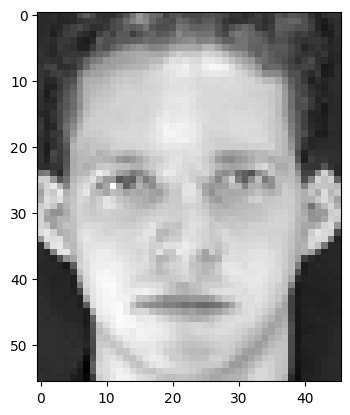

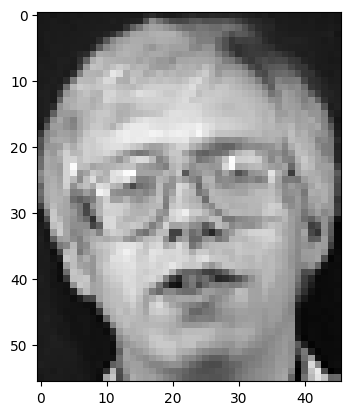

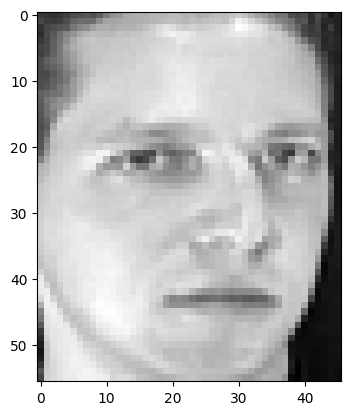

In [9]:
# we can see from the actual comparison in the picture in imshow of each picture below

plt.imshow(xf[0,0], cmap = 'gray')
plt.show()
plt.imshow(xf[1,0], cmap = 'gray')
plt.show()
plt.imshow(xf[0,1], cmap = 'gray')
plt.show()

This make no sense as the distance in the [0,0] and [0,1] is higher than [0,0] and [1,0] but when we actually see the face we can see that the face in [0,0] and [0,1] is actually the same with different angle while [0,0] and [1,0] is clearly a diffenrent person. 

This distance method can not be used in face recognition as it struggle to recognize same face in the diffenrent pose and lighting.

### T6.

In [10]:
def organize_shape(matrix):
    """
    TODO (Optional): Reduce matrix dimension of 2D image to 1D and merge people and image dimension.
    This function can be useful at organizing matrix shapes.

    Example:
        Input shape: (people_index, image_index, image_shape[0], image_shape[1])
        Output shape: (people_index*image_index, image_shape[0]*image_shape[1])
    """
    people_idx, img_idx, h, w = matrix.shape
    return matrix.reshape(people_idx * img_idx, h * w)


def generate_similarity_matrix(A, B):
    """
    TODO: Calculate similarity matrix M,
    which M[i, j] is a distance between A[i] and B[j].
    """
    num_A = A.shape[0]
    num_B = B.shape[0]
    similarity_matrix = np.zeros((num_A, num_B))
    
    for i in range(num_A):
        for j in range(num_B):
            similarity_matrix[i, j] = L2_dist(A[i], B[j])
    return similarity_matrix

def test_generate_similarity_matrix():
    test_A = np.array([[1, 2],[3,4]])
    test_B = np.array([[1, 2], [5, 6], [7, 8]])
    expected_matrix = np.sqrt(np.array([[0, 32, 72], [8, 8, 32]]))
    assert (generate_similarity_matrix(test_A, test_B) == expected_matrix).all()

test_generate_similarity_matrix()

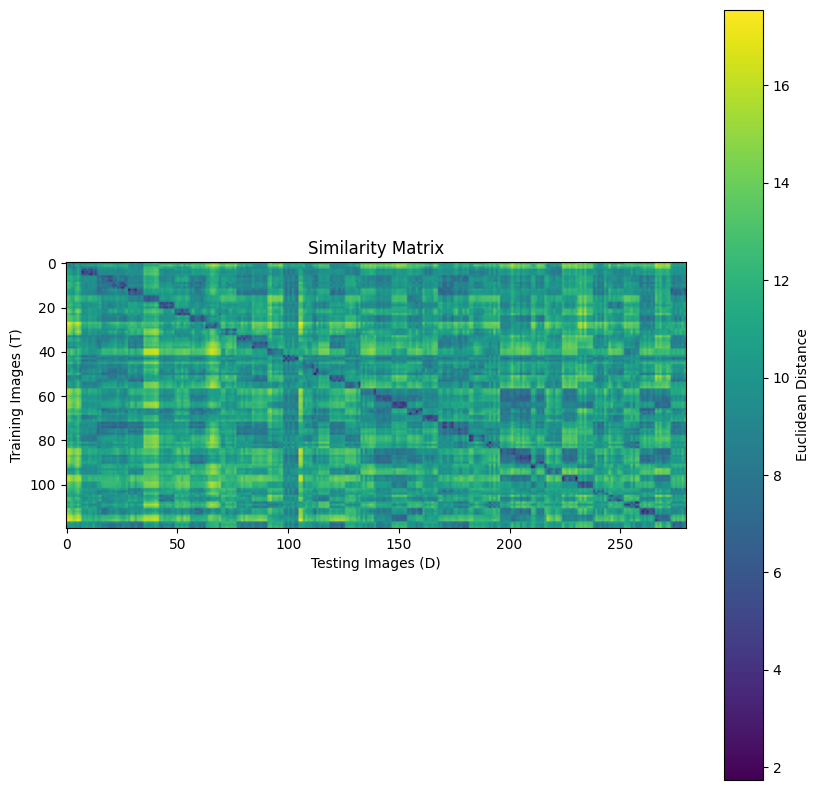

In [11]:
T = organize_shape(xf[:, :3])
D = organize_shape(xf[:, 3:])


similarity_matrix = generate_similarity_matrix(T, D)

plt.figure(figsize=(10, 10))
plt.imshow(similarity_matrix)
plt.colorbar(label='Euclidean Distance')
plt.title('Similarity Matrix')
plt.xlabel('Testing Images (D)')
plt.ylabel('Training Images (T)')
plt.show()

### T7. 


From the picture given, it seem that person 2 have high intra-class similarity and consistancy from the lower euclidiean distance suggested by the blackness of the area, this is imply that person 2 picture may have more consistant lighting and pose.

In contrast, person 1 show lighter gray in it's area wihich suggest it's higher intra-class distance, indicating the inconsistant in between picture such as diferent pose and such.

### T8. 

In [12]:
def evaluate_performance(similarity_matrix, threshold):
    """
    TODO: Calculate true positive rate and false alarm rate from given similarity_matrix and threshold.
    """
    num_people = 40
    num_train_per_person = 3
    num_test_per_person = 7
    num_test_images = similarity_matrix.shape[1]

    tp = 0
    fa = 0

    
    for j in range(num_test_images):
        actual_person_id = j // num_test_per_person
        
        for person_id in range(num_people):
            start_row = person_id * num_train_per_person
            end_row = start_row + num_train_per_person
            person_distances = similarity_matrix[start_row:end_row, j]
            
            is_match = np.any(person_distances <= threshold)
            
            if is_match:
                if person_id == actual_person_id:
                    tp += 1 
                else:
                    fa += 1

    
    total_positives = num_test_images 
    total_negatives = num_test_images * (num_people - 1) 

    true_pos_rate = tp / total_positives
    false_pos_rate = fa / total_negatives

    return true_pos_rate, false_pos_rate

evaluate_performance(similarity_matrix, 9.5)

(0.9928571428571429, 0.33507326007326005)

In [9]:
# t = 10 case
evaluate_performance(similarity_matrix, 10)

(0.9964285714285714, 0.4564102564102564)

### T9. 

Minimum should be 0, and maximum should be the highest Euclidean distance that we have

In [13]:
def calculate_roc(input_mat):
    """
    TODO: Calculate a list of true_pos_rate and a list of false_pos_rate from the given matrix.
    """

    min_t = 0
    max_t = np.max(input_mat)
    thresholds = np.linspace(min_t, max_t, 1000)

    tpr_list = []
    far_list = []
    
    for t in thresholds:
        tpr, far = evaluate_performance(input_mat, t)
        tpr_list.append(tpr)
        far_list.append(far)

    tpr_array = np.array(tpr_list)
    far_array = np.array(far_list)

    fnr_array = 1 - tpr_array
    eer_index = np.argmin(np.abs(far_array - fnr_array))
    eer_tpr = tpr_array[eer_index]

    target_far = 0.001
    recall_index = np.argmin(np.abs(far_array - target_far))
    recall_at_point_one = tpr_array[recall_index]
    return tpr_list, far_list, eer_tpr, recall_at_point_one

def plot_roc(input_mat):
    tpr_list, far_list, eer_tpr, recall_at_point_one= calculate_roc(input_mat)

    print(f'eer = {eer_tpr}')
    print(f'recall at 0.001 false negative = {recall_at_point_one}')

    plt.figure(figsize=(8, 6))
    plt.plot(far_list, tpr_list, color='yellow', lw=2, label='ROC curve')
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Alarm Rate (FAR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

eer = 0.9142857142857143
recall at 0.001 false negative = 0.5428571428571428


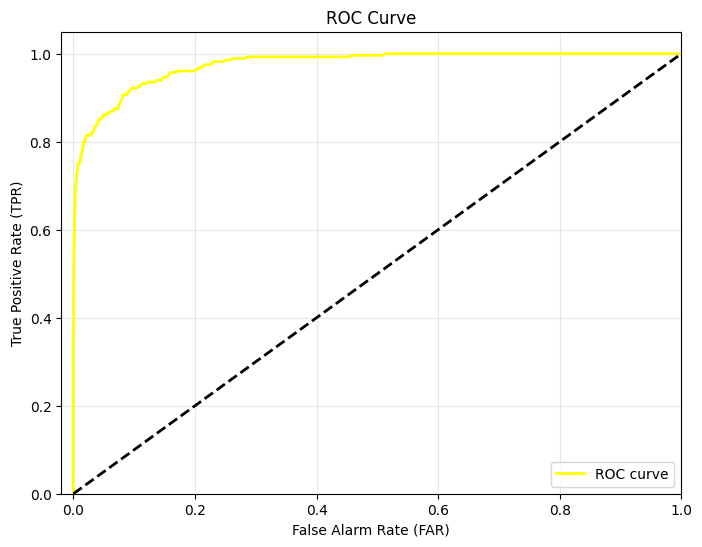

In [14]:
plot_roc(similarity_matrix)

### T10.



I answer together with T9. (included in function)

### T11.

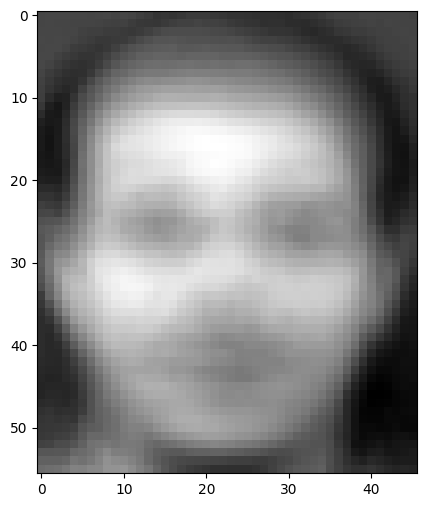

In [15]:
h, w = xf.shape[2], xf.shape[3]
meanface = np.mean(T.reshape(120, h*w), axis=0)

plt.figure(figsize=(5, 6))
plt.imshow(meanface.reshape(h, w), cmap='gray')
plt.show()

### T12.


In [16]:
x_hat = (T - meanface).T 
d, N = x_hat.shape
cov_size = (d, d)
cov_rank = N - 1
print(f"Covariance Matrix Size: {cov_size[0]} x {cov_size[1]}")
print(f"Covariance Matrix Rank: {cov_rank}")

Covariance Matrix Size: 2576 x 2576
Covariance Matrix Rank: 119


### T13.

In [17]:
gram_matrix =  x_hat.T @ x_hat

gram_size = gram_matrix.shape
gram_rank = np.linalg.matrix_rank(gram_matrix)

eigenvalues = np.linalg.eigvalsh(gram_matrix)
nonzero_eigenvalues = np.sum(eigenvalues > 1e-10)

Gram Matrix Size: 120 x 120
Gram Matrix Rank: 119
Number of Non-zero Eigenvalues: 119


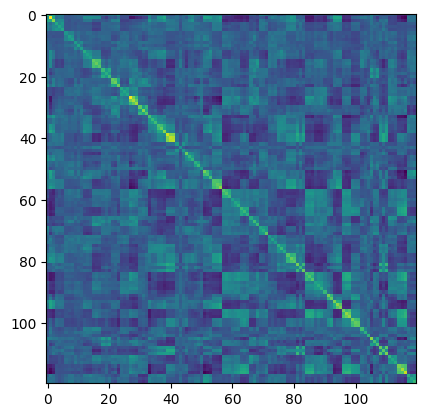

In [18]:
print(f"Gram Matrix Size: {gram_size[0]} x {gram_size[1]}")
print(f"Gram Matrix Rank: {gram_rank}")
print(f"Number of Non-zero Eigenvalues: {nonzero_eigenvalues}")
plt.imshow(gram_matrix)

### T14.


Gram matrix is symmatric. Using mathemetical prove,we can see that Gram matrix is
$$K = \hat{X}^T\hat{X}$$
which is equal to it's transpose (prove of symmetry)
$$K^T = ( \hat{X}^T\hat{X} )^T = \hat{X}^T ( \hat{X}^T )^T = \hat{X}^T\hat{X}$$

But we can also think of this with intuition as gram matrix is inner products of every sample pairs. For instance, element at i,j is sample i $\cdot$ sample j and element at j,i is sample j $\cdot$ sample i. Together with commutative attribute of dot product, this imply the symmetric attribute of gram matrix.

### T15.

In [19]:
# Hint: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html

def calculate_eigenvectors_and_eigenvalues(matrix):
    """
    TODO: Calculate eigenvectors and eigenvalues,
    then sort the eigenvalues and eigenvectors in descending order.

    Hint: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html
    """

    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    
    eigenvalues[np.isclose(eigenvalues, 0, atol=1e-10)] = 0

    return eigenvalues, eigenvectors

eigenvalues, eigenvectors = calculate_eigenvectors_and_eigenvalues(gram_matrix)

def test_eigenvalues_eigenvectors():
    # Dot product of an eigenvector pair should equal to zero.
    assert np.round(eigenvectors[10].dot(eigenvectors[20]), 10) == 0.0

    # Check if eigenvalues are sorted.
    assert list(eigenvalues) == sorted(eigenvalues, reverse = True)

test_eigenvalues_eigenvectors()

In [20]:
eigenvalues, eigenvectors = calculate_eigenvectors_and_eigenvalues(gram_matrix)
count = np.count_nonzero(eigenvalues)
print(f"Number of non-zero eigenvalues: {count}")

Number of non-zero eigenvalues: 119


### T16.

We can use the explained variance analysis to determine the eigen vector to use

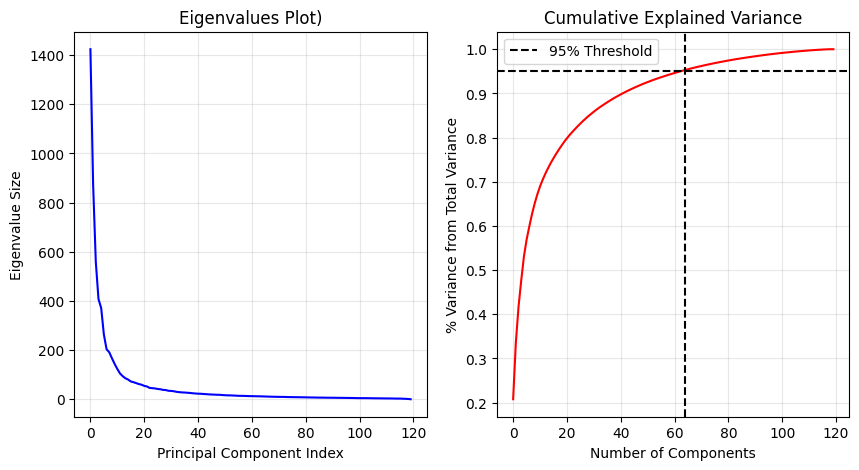

Number of eigenvectors needed for 95% variance: 64


In [21]:
total_variance = np.sum(eigenvalues)

explained_variance_ratio = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(10, 5))

# Eigenvalues Plot
plt.subplot(1, 2, 1)
plt.plot(eigenvalues, 'b-')
plt.title('Eigenvalues Plot)')
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue Size')
plt.grid(alpha=0.3)

# Cumulative Explained Variance (for 95% count)
plt.subplot(1, 2, 2)
plt.plot(cumulative_variance, 'r-')
plt.axhline(y=0.95, color='black', linestyle='--', label='95% Threshold')
plt.axvline(x=n_components_95, color='black', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('% Variance from Total Variance')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(f"Number of eigenvectors needed for 95% variance: {n_components_95}")


### T17.

In [22]:
# TODO: Compute v, then renormalize it.
v = x_hat @ eigenvectors

norms = np.linalg.norm(v, axis=0)
v = v / norms

In [23]:
def test_eignevector_cov_norm(v):
    assert (np.round(np.linalg.norm(v, axis=0), 1) == 1.0).all()

test_eignevector_cov_norm(v)

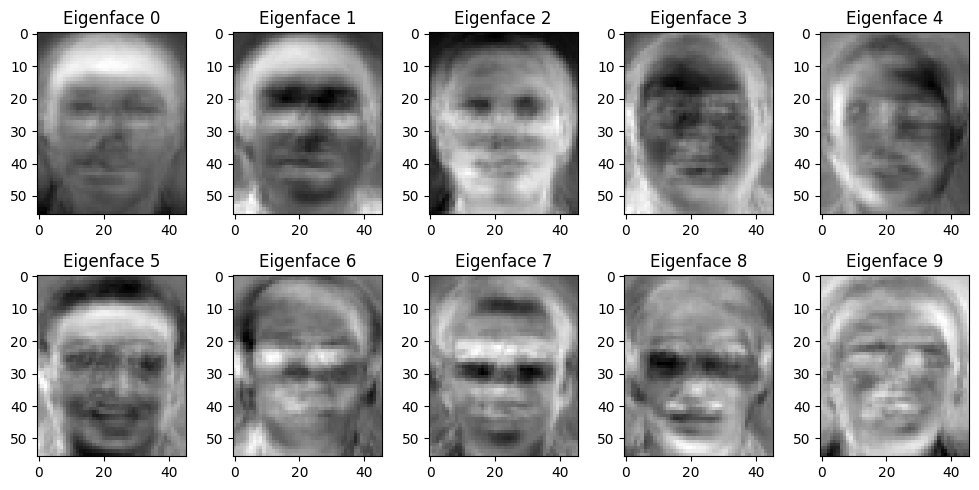

In [24]:
# TODO: Show the first 10 eigenvectors as images.
h, w = 56, 46
plt.figure(figsize=(10, 5))
for i in range(10):
   plt.subplot(2, 5, i + 1)
   plt.title(f"Eigenface {i}") 
   plt.tight_layout()
   plt.imshow(v[:, i].reshape(56,46), cmap='gray')

### T18.

Eigenface0 mostly captures the lighting of the picture specifically in the top part of the face. Eigenface1 captures both face structure and lighting of the person face. 

The biggest variance is not in both picture as their are whiteer or blacker area in other picture which indicate more variance.

### T19.

In [25]:
def calculate_projection_vectors(matrix, meanface, v, k):
    """
    TODO: Find the projection vectors on v from given matrix and meanface.
    """

    centered_matrix = matrix - meanface

    v_k = v[:, :k]
    projection_vectors = centered_matrix @ v_k

    return projection_vectors

In [26]:
# TODO: Get projection vectors of T and D, then Keep first k projection values.
k = 10
T_reduced = calculate_projection_vectors(T, meanface, v, k=10)
D_reduced = calculate_projection_vectors(D, meanface, v, k=10)


def test_reduce_dimension():
    assert T_reduced.shape[-1] == k
    assert D_reduced.shape[-1] == k

test_reduce_dimension()

In [29]:
reduced_similarity_matrix = generate_similarity_matrix(T_reduced, D_reduced)

eer = 0.9214285714285714
recall at 0.001 false negative = 0.5178571428571429


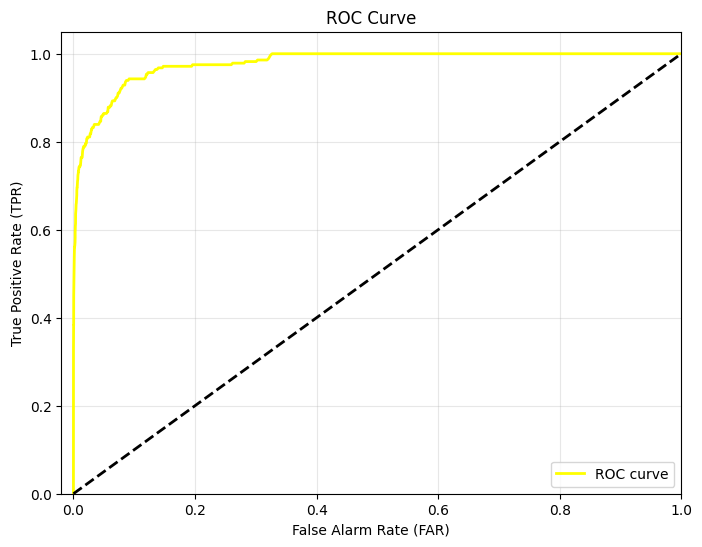

In [30]:
plot_roc(reduced_similarity_matrix)

### T20.


k = 5
EER (TPR) = 0.8928571428571429
Recall at 0.001 = 0.25357142857142856


k = 6
EER (TPR) = 0.9071428571428571
Recall at 0.001 = 0.35


k = 7
EER (TPR) = 0.9071428571428571
Recall at 0.001 = 0.4107142857142857


k = 8
EER (TPR) = 0.9142857142857143
Recall at 0.001 = 0.40714285714285714


k = 9
EER (TPR) = 0.9178571428571428
Recall at 0.001 = 0.45357142857142857


k = 10
EER (TPR) = 0.9214285714285714
Recall at 0.001 = 0.5178571428571429


k = 11
EER (TPR) = 0.9214285714285714
Recall at 0.001 = 0.5035714285714286


k = 12
EER (TPR) = 0.9142857142857143
Recall at 0.001 = 0.5107142857142857


k = 13
EER (TPR) = 0.9214285714285714
Recall at 0.001 = 0.5178571428571429


k = 14
EER (TPR) = 0.9178571428571428
Recall at 0.001 = 0.5071428571428571


best EER = 0.9214285714285714


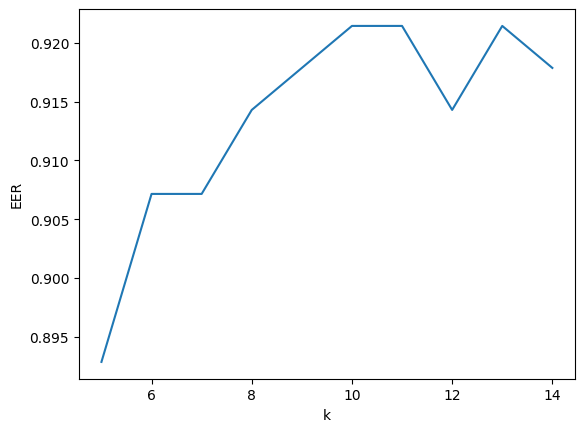

In [34]:
k_s = list(range(5, 15))
res=[]
best_eer = 0

for k in k_s: 
    print(f'k = {k}')
    T_reduced = calculate_projection_vectors(T,meanface,v,k)
    D_reduced = calculate_projection_vectors(D,meanface,v,k)

    similarity_matrix = generate_similarity_matrix(T_reduced,D_reduced)
    
    tpr_list, far_list, eer_tpr, recall_at_point_one=calculate_roc(similarity_matrix)
    print(f'EER (TPR) = {eer_tpr}')
    res.append(eer_tpr)
    print(f'Recall at 0.001 = {recall_at_point_one}')
    print("\n")

    best_eer = max(eer_tpr,best_eer)

plt.plot(k_s,res)
plt.xlabel("k")
plt.ylabel("EER")
print(f'best EER = {best_eer}')

It's at K=13

### OT2.

MSE : 0.006148335016488303


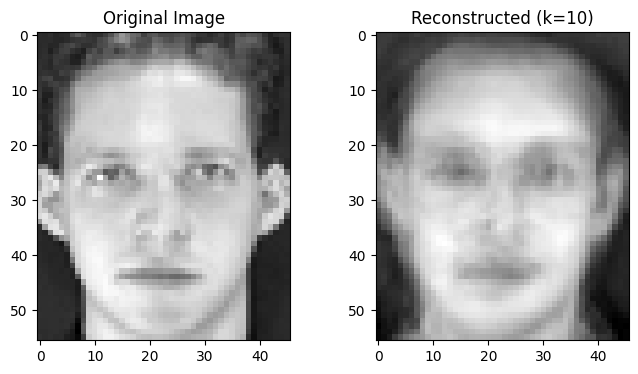

In [29]:
k = 10
T_reduced = calculate_projection_vectors(T, meanface, v, k)
p = T_reduced[0, :k]

original_image = T[0]

reconstructed_image = meanface + (v[:, :k] @ p)

mse = np.mean((original_image - reconstructed_image)**2)

print(f"MSE : {mse}")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(original_image.reshape(h, w), cmap='gray')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image.reshape(h, w), cmap='gray')
plt.title(f"Reconstructed (k={k})")
plt.show()

### OT2.

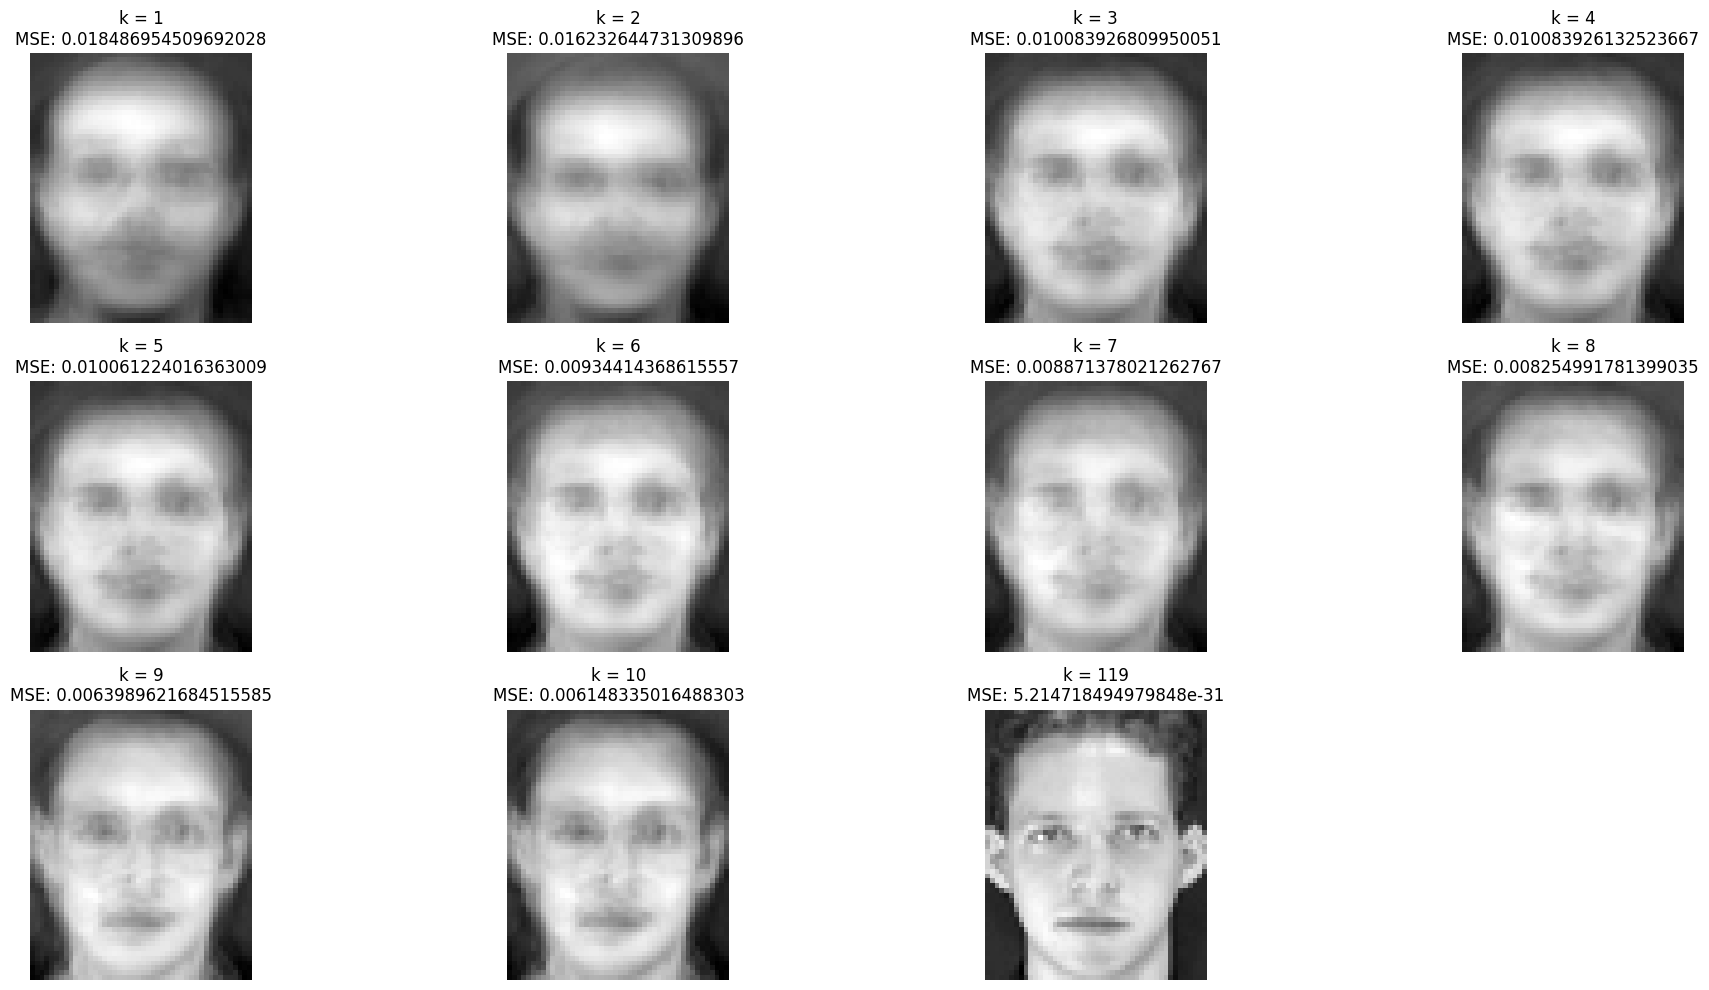

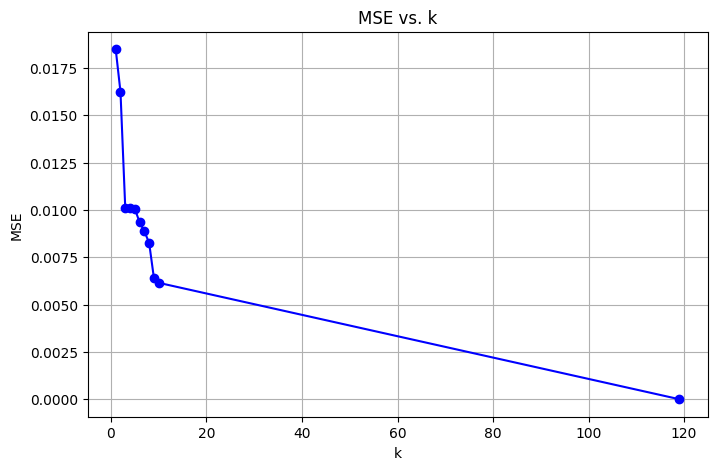

In [32]:
k_s = x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 119])
mse_results = []
original_img = T[0]

plt.figure(figsize=(20, 10))

for i, k in enumerate(k_s):
   T_reduced = calculate_projection_vectors(T, meanface, v, k)
   reconstructed = meanface + (v[:, :k] @ T_reduced[0, :k])
    
   error = np.mean((original_img - reconstructed)**2)
   mse_results.append(error)
    
   plt.subplot(3, 4, i + 1)
   plt.imshow(reconstructed.reshape(h, w), cmap='gray')
   plt.title(f"k = {k}\nMSE: {error}")
   plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_s, mse_results, marker='o', linestyle='-', color='b')
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("MSE vs. k")
plt.grid(True)
plt.show()

### OT4.

Original images size is 56 x 46 = 2,576 pixels. Consider that each pixels is store with 32-bit floats, we would need 2,576 x 4 x 1e6 = 10,304,000,000 bytes or 10.3 GB to store 1,000,000 original images

While in compressed version, we only required 10 eigenvalues per images which is 40 bytes. For 1,000,000 compressed image, the size is 40,000,000 bytes or 40 MB. Additionally, we need to store meanface (1 original image size), 10 eigenfaces (10 original images size) which is 2,576 x 4 x 11 = 113,344 bytes or 0.113 MB. Total compressed size for 1,000,000 compresses images would be approximately 40.113 Mb

### T21. 

We should try to get the dimension to be less or equel to the difference of number of sample and number of class

In [35]:
# TODO: Define dimension of PCA.
n_dim = 120 - 40 # from the sample count - number of people to classify

# TODO: Find PCA of T and D with n_dim dimension.
T_reduced = calculate_projection_vectors(T, meanface, v, n_dim)
D_reduced = calculate_projection_vectors(D, meanface, v, n_dim)

print(f"Dimension = {n_dim}")

print(f"PCA of T = {T_reduced.shape}")
print(f"PCA of D = {D_reduced.shape}")

Dimension = 80
PCA of T = (120, 80)
PCA of D = (280, 80)


### T22.

In [57]:
# TODO: Find the LDA projection.
n_people, n_samples = 40, 3
T_reshaped = T_reduced.reshape((n_people, n_samples, -1))

class_means = T_reshaped.mean(axis=1)
total_mean = class_means.mean(axis=0)

mean_difference = class_means - total_mean

S_b = mean_difference.T @ mean_difference
S_w = np.zeros((T_reduced.shape[1], T_reduced.shape[1]))

for i in range(n_people):
   centered_class = T_reshaped[i] - class_means[i]
   S_w += centered_class.T @ centered_class

lda_matrix = np.linalg.inv(S_w) @ S_b
lda_eigenvalues, lda_eigenvectors = np.linalg.eig(lda_matrix)

lda_eigenvectors = lda_eigenvectors.real
lda_eigenvalues = lda_eigenvalues.real


print(f"LDA Matrix symmetric?: {np.allclose(lda_matrix, lda_matrix.T)}")
print(f"Non-zero Eigenvalues: {np.where(lda_eigenvalues>1e-20, 1, 0).sum()}")


LDA Matrix symmetric?: False
Non-zero Eigenvalues: 56


We cant use  numpy.linalg.eigh as our lda matrix is not symmetric.

### T23.

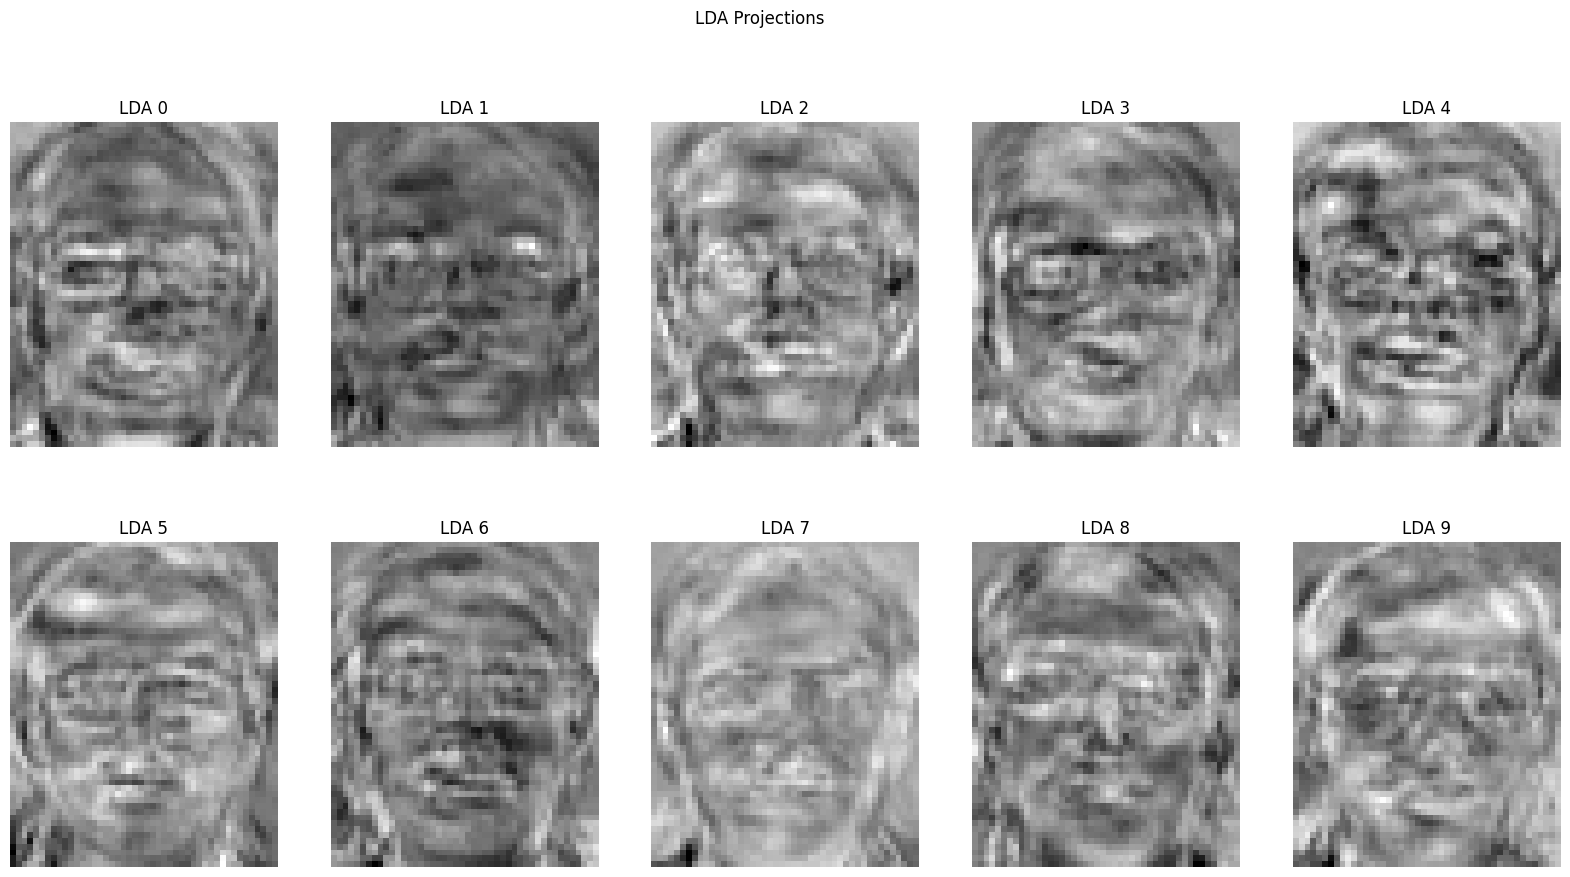

In [60]:
lda_projections = v[:, :80] @ lda_eigenvectors[:, :10]


plt.figure(figsize=(20, 10))
for i in range(10):
   plt.subplot(2, 5, i + 1)
   plt.imshow(lda_projections[:, i].reshape(h, w), cmap='gray')
   plt.title(f"LDA {i}")
   plt.axis('off')

plt.suptitle("LDA Projections")
plt.show()

The PCA projection seem to be more smooth and focus on highlighting the lighting and shadow in the face picture. While LDA projection ignore lighting and shadow and focus on highligting the face shape and structure which make it visually less smooth.

### T24.

In [73]:
k_lda = 39
T_fisher = calculate_projection_vectors(T_reduced, np.zeros(n_dim), lda_eigenvectors, k_lda)
D_fisher = calculate_projection_vectors(D_reduced, np.zeros(n_dim), lda_eigenvectors, k_lda)

fisher_similarity_matrix = generate_similarity_matrix(T_fisher, D_fisher)

eer = 0.9285714285714286
recall at 0.001 false negative = 0.6821428571428572


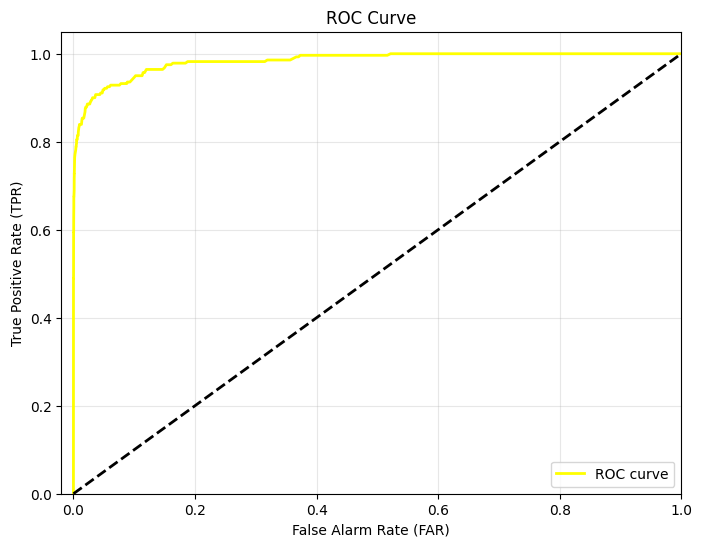

In [74]:
plot_roc(fisher_similarity_matrix)

### T25.

In [75]:
tpr_raw, far_raw, _, _ = calculate_roc(similarity_matrix)
tpr_pca, far_pca, _, _ = calculate_roc(reduced_similarity_matrix)
tpr_fisher, far_fisher, _, _ = calculate_roc(fisher_similarity_matrix)

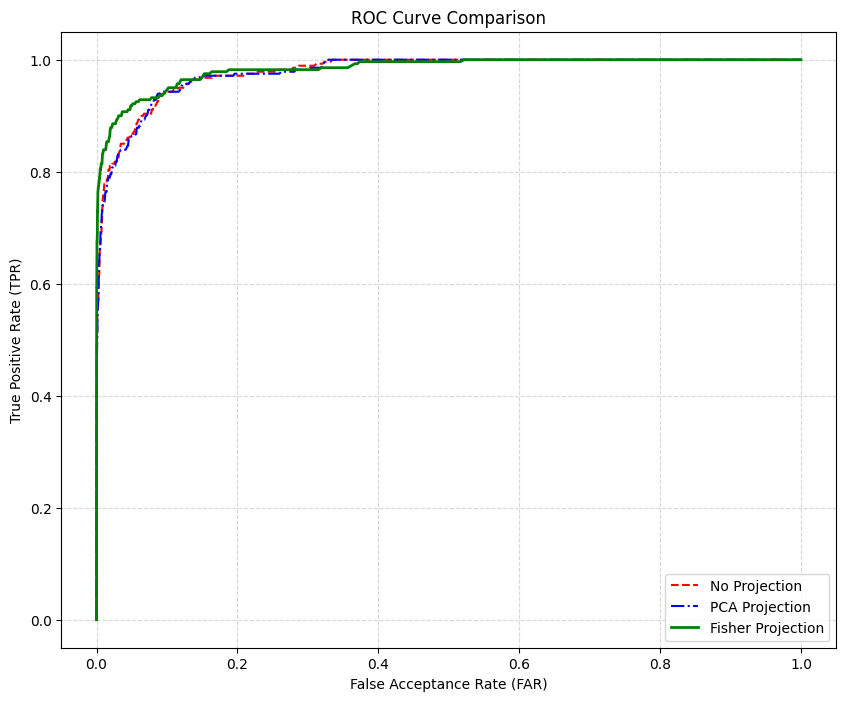

In [77]:
plt.figure(figsize=(10, 8))
plt.plot(far_raw, tpr_raw, label='No Projection', color='red', linestyle='--')
plt.plot(far_pca, tpr_pca, label='PCA Projection', color='blue', linestyle='-.')
plt.plot(far_fisher, tpr_fisher, label='Fisher Projection', color='green', linewidth=2)
plt.xlabel('False Acceptance Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

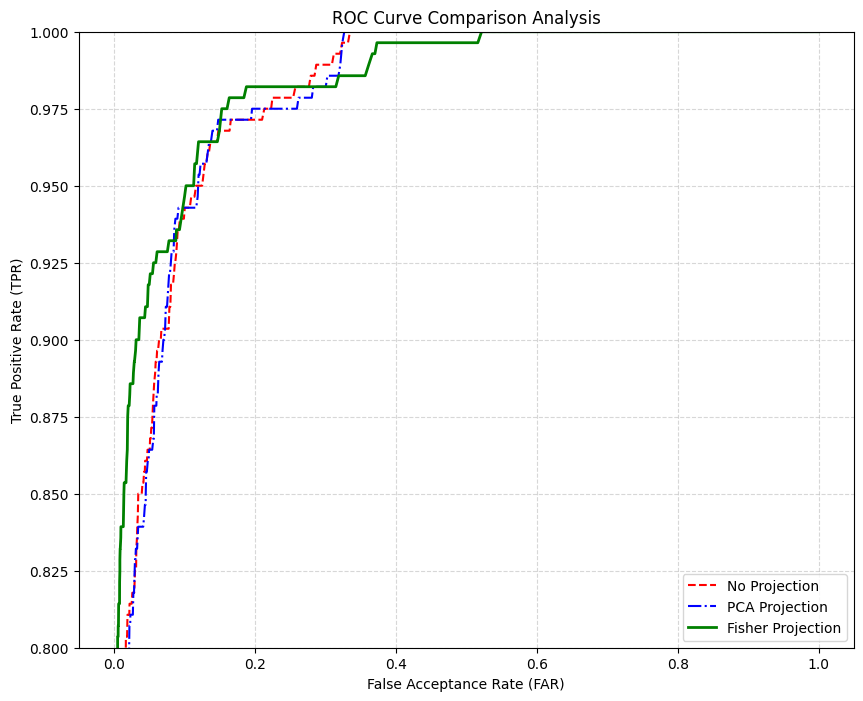

In [79]:
plt.figure(figsize=(10, 8))
plt.plot(far_raw, tpr_raw, label='No Projection', color='red', linestyle='--')
plt.plot(far_pca, tpr_pca, label='PCA Projection', color='blue', linestyle='-.')
plt.plot(far_fisher, tpr_fisher, label='Fisher Projection', color='green', linewidth=2)
plt.ylim(0.8, 1.0) 
#plt.xlim(0.0, 0.6)
plt.xlabel('False Acceptance Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison Analysis')
plt.legend(loc='lower right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

The ROC plot above show that fisher projection display the best result but struggle more than other projection when TPR is over 0.975. PCA and no projection show similar result with no major difference to observe, both projection show struggle to increase after 0.975 TPR.

### OT5.

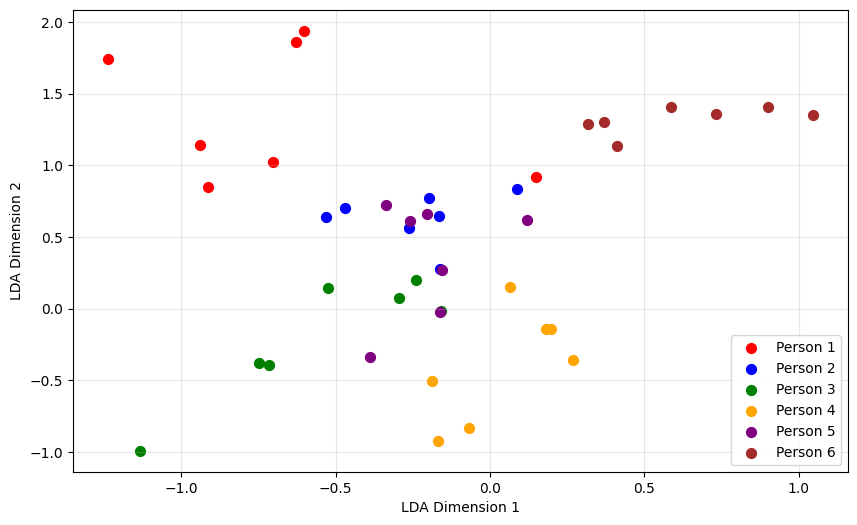

In [83]:
n_people = 6
n_samples = 7
test_subset = D_fisher[:n_people * n_samples, :2]

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i in range(n_people):
   start = i * n_samples
   end = start + n_samples
   plt.scatter(test_subset[start:end, 0], test_subset[start:end, 1], color=colors[i], label=f'Person {i+1}', s=50)

plt.xlabel("LDA Dimension 1")
plt.ylabel("LDA Dimension 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

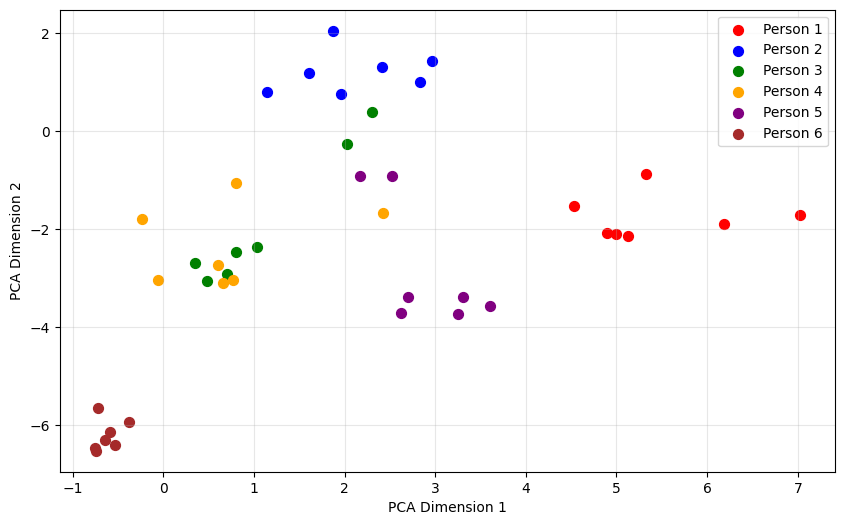

In [ ]:
D_pca = calculate_projection_vectors(D, meanface, v, 2)
test_subset_pca = D_pca[:n_people * n_samples]

plt.figure(figsize=(10, 6))
for i in range(n_people):
    start = i * n_samples
    end = start + n_samples
    plt.scatter(test_subset_pca[start:end, 0], test_subset_pca[start:end, 1], color=colors[i], label=f'Person {i+1}', s=50)

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

From both scatter plot, PCA achieve decent result with some classes or persons actually distinct from others. However, some classes such as person 3, 4, 5 are mixed with other classes and would yield poor performance in real face recognition models.

LDA have the similar result with a little mixed classes but show a decent grouping ability (less outlier from main group). Each classes also show significant in distinct direction from the middle area whihc mean the LDA projection allow each classes to have distict from others, good for face recognition task.